# Task 1: Quantum Computing Part

1) implement a simple quantum operation with Cirq or Pennylane <br>
  a) With 5 qubits <br>
  b) Apply Hadamard operation on every qubit <br>
  c) Apply CNOT operation on (0, 1), (1,2), (2,3), (3,4) <br>
  d) SWAP (0, 4) <br>
  e) Rotate X with pi/2 on any qubit <br>
  f) Plot the circuit


In [ ]:
!pip install cirq -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 79.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 670.8/670.8 kB 56.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.5/73.5 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 430.5/430.5 kB 43.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 107.9 MB/s eta 0:00:00


In [ ]:
import cirq

In [ ]:
#a) 5 qubits circuit
q = cirq.LineQubit.range(5)

ref. to visualize circuit: https://quantumcomputing.stackexchange.com/questions/16521/in-cirq-how-do-you-display-circuit-diagrams-that-are-prettier-than-the-ones-d

In [ ]:
from cirq.contrib.svg import SVGCircuit

In [ ]:
#b) applying Hadamard operation on every qubit
circuit = cirq.Circuit()

for qubit in q:
  circuit.append(cirq.H(qubit))

In [ ]:
circuit

0: ───H───

1: ───H───

2: ───H───

3: ───H───

4: ───H───

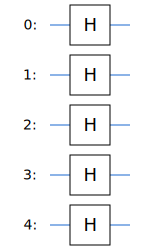

In [ ]:
SVGCircuit(circuit)

In [ ]:
#c) applying CNOT operation on (0, 1), (1,2), (2,3), (3,4)
circuit.append(cirq.CNOT(q[0],q[1]))
circuit.append(cirq.CNOT(q[1],q[2]))
circuit.append(cirq.CNOT(q[2],q[3]))
circuit.append(cirq.CNOT(q[3],q[4]))

SWAP method: https://quantumai.google/reference/python/cirq/SWAP

In [ ]:
#d) SWAP (0,4)
circuit.append(cirq.SWAP(q[0],q[4]))

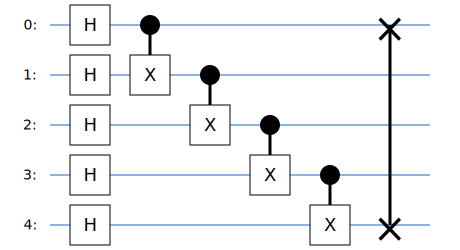

In [ ]:
SVGCircuit(circuit)

cirq.rx(rads) A rotation about the Pauli 'X' axis in terms of radians. This is equivalent to exp(-i X rads / 2) = cos(rads/2) I - i sin(rads/2) X

https://quantumai.google/cirq/build/gates

https://quantumai.google/reference/python/cirq/rx

In [ ]:
import numpy as np

#e) Rotate X with pi/2 on any qubit
#in my case, choosing qubit 3
circuit.append(cirq.rx(np.pi/2)(q[3]))

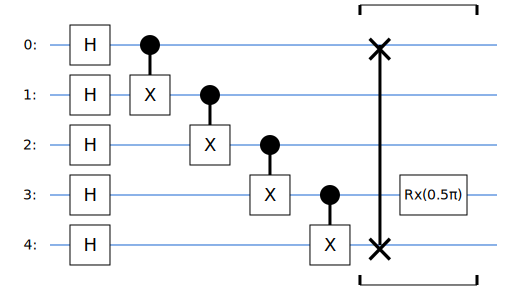

In [ ]:
#f) plotting the circuit
SVGCircuit(circuit)

2) Implement a second circuit with a framework of your choice: <br>
a) Apply a Hadmard gate to the first qubit <br>
b) rotate the second qubit by pi/3 around X <br>
c) Apply Hadamard gate to the third and fourth qubit <br>
d) Perform a swap test between the states of the first and second qubit |q1 q2> and the third and fourth qubit |q3 q4>


https://docs.pennylane.ai/en/stable/introduction/circuits.html

In [ ]:
#using pennylane
!pip install pennylane -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.2/57.2 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 54.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 32.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 74.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 37.3 MB/s eta 0:00:00


In [ ]:
import pennylane as qml

In [ ]:
dev = qml.device("default.qubit",wires=5)

In [ ]:
@qml.qnode(dev)
def circuit():
  return qml.probs(wires=0)

In [ ]:
print(qml.draw(circuit)())

0: ───┤  Probs


In [ ]:
#a) applying Hadamard gate to the first qubit
@qml.qnode(dev)
def circuit():
  qml.Hadamard(wires=1)
  return qml.probs(wires=0)

In [ ]:
print(qml.draw(circuit)())

0: ────┤  Probs
1: ──H─┤       


In [ ]:
@qml.qnode(dev)
def circuit():
  #a) applying Hadamard gate to the first qubit (q1 being wire 1)
  qml.Hadamard(wires=1)

  #b) rotate the second qubit by pi/3 around X
  qml.RX(np.pi/3, wires=2)

  #c) applying Hadamard gate to the third and fourth qubits (q3, q4)
  qml.Hadamard(wires=3)
  qml.Hadamard(wires=4)


  #d) swap test between |q1 q2> and |q3 q4>
  qml.Hadamard(wires=0)
  qml.CSWAP(wires=[0, 1, 3])
  qml.CSWAP(wires=[0, 2, 4])
  qml.Hadamard(wires=0)

  return qml.probs(wires=0)

In [ ]:
print(qml.draw(circuit)())

0: ──H────────╭●────╭●─────H─┤  Probs
1: ──H────────├SWAP─│────────┤       
2: ──RX(1.05)─│─────├SWAP────┤       
3: ──H────────╰SWAP─│────────┤       
4: ──H──────────────╰SWAP────┤       


# Task 2 : Classical Graph Neural Network (GNN)


In [ ]:
!pip install torch-geometric -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 31.3 MB/s eta 0:00:00


In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.data import Data, Dataset
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, GATConv, global_mean_pool, global_max_pool
from torch_geometric.nn import EdgeConv

from torch.optim import AdamW
from sklearn.model_selection import train_test_split

from sklearn.metrics import roc_auc_score, accuracy_score, roc_curve, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Device: cuda


In [ ]:
CONFIG = {
    "batch_size": 64,
    "epochs": 40,
    "lr": 1e-3,
    "weight_decay": 1e-4,
    "k_neighbors": 24,
    "gcn_hidden_dims": [64, 128, 256],
    "gat_hidden_dims": [64, 128, 256],
    "gat_heads": 4,
    "dropout_rate": 0.3,
}

In [ ]:
!pip install energyflow -q

In [ ]:
import energyflow as ef

In [ ]:
X, y = ef.qg_jets.load(
    num_data=50000,
    pad=True,
    generator="pythia",
    with_bc=False
)
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (50000, 139, 4)
y shape: (50000,)


In [ ]:
from sklearn.neighbors import NearestNeighbors
from tqdm import tqdm

In [ ]:
def knn_graph(jet, k=CONFIG["k_neighbors"]):
  mask = jet[:,0] > 0
  jet = jet[mask]

  if len(jet) < 3:
    return None, None

  pt  = jet[:,0]
  eta = jet[:,1]
  phi = jet[:,2]
  pid = jet[:,3]

  jet_pt = np.sum(pt)

  log_pt = np.log(pt + 1e-8)
  rel_pt = np.log(pt / jet_pt + 1e-8)

  eta_center = np.sum(pt * eta) / jet_pt
  phi_center = np.sum(pt * phi) / jet_pt

  d_eta = eta - eta_center
  d_phi = phi - phi_center

  d_phi = (d_phi + np.pi) % (2*np.pi) - np.pi

  abs_pid = np.abs(pid)

  is_photon = (abs_pid == 22).astype(np.float32)
  is_electron = (abs_pid == 11).astype(np.float32)
  is_muon = (abs_pid == 13).astype(np.float32)
  is_charged = np.isin(abs_pid, [211,321,2212]).astype(np.float32)

  node_features = np.stack([
      log_pt,
      rel_pt,
      d_eta,
      d_phi,
      is_photon,
      is_electron,
      is_muon,
      is_charged
  ], axis=1)

  x = torch.tensor(node_features, dtype=torch.float)

  coords = np.stack([d_eta, d_phi], axis=1)

  k = min(k, len(coords)-1)

  nbrs = NearestNeighbors(n_neighbors=k+1).fit(coords)
  _, indices = nbrs.kneighbors(coords)

  edges = []
  for i in range(len(coords)):
    for j in indices[i][1:]:
      edges.append([i,j])
      edges.append([j,i])

  edge_index = torch.tensor(edges).t().contiguous()

  return x, edge_index

In [ ]:
from tqdm import tqdm

graphs = []
num_skipped_graphs = 0

for jet, label in tqdm(zip(X, y), total=len(X)):
  x, edge_index = knn_graph(jet, CONFIG["k_neighbors"])

  if x is None or edge_index is None:
      num_skipped_graphs += 1
      continue

  data = Data(
      x=x,
      edge_index=edge_index,
      y=torch.tensor([label], dtype=torch.long)
  )
  graphs.append(data)

100%|██████████| 50000/50000 [03:49<00:00, 217.82it/s]


In [ ]:
all_x = torch.cat([g.x for g in graphs], dim=0)

mean = all_x.mean(dim=0)
std = all_x.std(dim=0) + 1e-6

for g in graphs:
  g.x = (g.x - mean) / std

In [ ]:
print(f"Total graphs created: {len(graphs)}")
print(f"Total graphs skipped (too few particles): {num_skipped_graphs}")

train_graphs, test_graphs = train_test_split(
    graphs, test_size=0.2, random_state=42
)
val_graphs, test_graphs = train_test_split(
    test_graphs, test_size=0.5, random_state=42
)

train_loader = DataLoader(
    train_graphs,
    batch_size=CONFIG["batch_size"],
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_graphs,
    batch_size=CONFIG["batch_size"],
    num_workers=0
)

test_loader = DataLoader(
    test_graphs,
    batch_size=CONFIG["batch_size"],
    num_workers=0
)

Total graphs created: 50000
Total graphs skipped (too few particles): 0


In [ ]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
if graphs:
    NODE_FEATURE_DIM = graphs[0].x.shape[1]
else:
    NODE_FEATURE_DIM = 8
print(f"Node feature dimension: {NODE_FEATURE_DIM}")

Node feature dimension: 8


## architecture 1 - GCN

In [ ]:
class GCN(nn.Module):
  def __init__(self):

    super().__init__()

    self.conv1 = GCNConv(NODE_FEATURE_DIM, 128)
    self.conv2 = GCNConv(128, 256)
    self.conv3 = GCNConv(256, 256)
    self.conv4 = GCNConv(256, 256)

    self.bn1 = nn.BatchNorm1d(128)
    self.bn2 = nn.BatchNorm1d(256)
    self.bn3 = nn.BatchNorm1d(256)
    self.bn4 = nn.BatchNorm1d(256)

    self.mlp = nn.Sequential(
        nn.Linear(512,256),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(256,128),
        nn.ReLU(),
        nn.Linear(128,2)
    )

  def forward(self,x,edge_index,batch):

    x = F.relu(self.bn1(self.conv1(x,edge_index)))
    x = F.relu(self.bn2(self.conv2(x,edge_index)))
    x = F.relu(self.bn3(self.conv3(x,edge_index)))
    x = F.relu(self.bn4(self.conv4(x,edge_index)))

    mean = global_mean_pool(x,batch)
    maxp = global_max_pool(x,batch)

    x = torch.cat([mean,maxp],dim=1)

    return self.mlp(x)

## architecture 2 - GAT

In [ ]:
class GAT(nn.Module):
  def __init__(self, node_feat_dim=NODE_FEATURE_DIM, heads=CONFIG["gat_heads"], dropout=CONFIG["dropout_rate"]):
    super().__init__()
    hidden = 128
    self.gat1 = GATConv(node_feat_dim, hidden, heads=heads, dropout=dropout)
    self.bn1 = nn.BatchNorm1d(hidden * heads)
    self.gat2 = GATConv(hidden * heads, hidden, heads=heads, dropout=dropout)
    self.bn2 = nn.BatchNorm1d(hidden * heads)
    self.gat3 = GATConv(hidden * heads, hidden, heads=heads, dropout=dropout)
    self.bn3 = nn.BatchNorm1d(hidden * heads)
    self.gat4 = GATConv(hidden * heads, hidden, heads=1, concat=False, dropout=dropout)
    self.bn4 = nn.BatchNorm1d(hidden)
    self.dropout = dropout
    self.mlp = nn.Sequential(
        nn.Linear(hidden * 2, 256),
        nn.ReLU(),
        nn.Dropout(dropout),

        nn.Linear(256, 128),
        nn.ReLU(),
        nn.Dropout(dropout),

        nn.Linear(128, 2)
    )

  def forward(self, x, edge_index, batch):

    x0 = x
    x = self.gat1(x, edge_index)
    x = self.bn1(x)
    x = F.elu(x)
    x = F.dropout(x, p=self.dropout, training=self.training)
    x = self.gat2(x, edge_index)
    x = self.bn2(x)
    x = F.elu(x)
    x = F.dropout(x, p=self.dropout, training=self.training)
    x = self.gat3(x, edge_index)
    x = self.bn3(x)
    x = F.elu(x)
    x = F.dropout(x, p=self.dropout, training=self.training)
    x = self.gat4(x, edge_index)
    x = self.bn4(x)
    x = F.elu(x)
    mean_pool = global_mean_pool(x, batch)
    max_pool  = global_max_pool(x, batch)
    x = torch.cat([mean_pool, max_pool], dim=1)

    return self.mlp(x)

## architecture 3 - ParticleNet

In [ ]:
def knn_graph_torch(x, batch, k):

  edge_index_list = []
  start = 0

  for b in batch.unique():

    mask = (batch == b)
    x_b = x[mask]

    n = x_b.size(0)

    if n <= k:
        k_use = n - 1
    else:
        k_use = k

    dist = torch.cdist(x_b, x_b)

    knn = dist.topk(k_use + 1, largest=False).indices[:,1:]

    row = torch.arange(n, device=x.device).view(-1,1).repeat(1,k_use).reshape(-1)
    col = knn.reshape(-1)

    edge = torch.stack([row + start, col + start], dim=0)

    edge_index_list.append(edge)

    start += n

  return torch.cat(edge_index_list, dim=1)

In [ ]:
class ParticleNetBlock(nn.Module):

  def __init__(self, in_dim, out_dim, k=16):

    super().__init__()

    self.k = k

    self.mlp = nn.Sequential(
        nn.Linear(in_dim * 2, out_dim),
        nn.BatchNorm1d(out_dim),
        nn.ReLU(),

        nn.Linear(out_dim, out_dim),
        nn.BatchNorm1d(out_dim),
        nn.ReLU()
    )

    self.edgeconv = EdgeConv(self.mlp, aggr="max")

  def forward(self, x, batch):

    edge_index = knn_graph_torch(x, batch, self.k)

    return self.edgeconv(x, edge_index)

In [ ]:
class ParticleNet(nn.Module):

  def __init__(self, node_feat_dim):
    super().__init__()
    self.block1 = ParticleNetBlock(node_feat_dim, 64, k=24)
    self.block2 = ParticleNetBlock(64, 128, k=24)
    self.block3 = ParticleNetBlock(128, 256, k=24)

    self.mlp = nn.Sequential(
        nn.Linear(512,256),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(256,128),
        nn.ReLU(),
        nn.Linear(128,2)
    )

  def forward(self, x, batch):

    x = self.block1(x, batch)
    x = self.block2(x, batch)
    x = self.block3(x, batch)
    mean = global_mean_pool(x, batch)
    maxp = global_max_pool(x, batch)
    x = torch.cat([mean,maxp], dim=1)

    return self.mlp(x)

In [ ]:
@torch.no_grad()
def evaluate_particlenet(model, loader):

  model.eval()

  ys = []
  preds = []
  probs = []

  for batch in loader:

    batch = batch.to(device)

    out = model(batch.x, batch.batch)

    prob = torch.softmax(out, dim=1)[:,1]
    pred = out.argmax(dim=1)

    ys.append(batch.y.cpu())
    preds.append(pred.cpu())
    probs.append(prob.cpu())

  ys = torch.cat(ys).numpy()
  preds = torch.cat(preds).numpy()
  probs = torch.cat(probs).numpy()

  acc = accuracy_score(ys, preds)
  auc = roc_auc_score(ys, probs)

  return acc, auc, ys, preds, probs

## train and evaluation functions

In [ ]:
def train_epoch(model, loader, optimizer):
  model.train()
  total_loss = 0
  for batch in loader:
    batch = batch.to(device)
    optimizer.zero_grad()
    out = model(batch.x, batch.edge_index, batch.batch)
    loss = F.cross_entropy(out, batch.y)
    loss.backward()
    optimizer.step()
    total_loss += loss.item()
  return total_loss / len(loader)

In [ ]:
@torch.no_grad()
def evaluate(model, loader):
  model.eval()
  ys = []
  preds = []
  probs = []
  for batch in loader:
    batch = batch.to(device)
    out = model(batch.x, batch.edge_index, batch.batch)
    prob = torch.softmax(out, dim=1)[:,1]
    pred = out.argmax(dim=1)
    ys.append(batch.y.cpu())
    preds.append(pred.cpu())
    probs.append(prob.cpu())
  ys = torch.cat(ys).numpy()
  preds = torch.cat(preds).numpy()
  probs = torch.cat(probs).numpy()
  acc = accuracy_score(ys, preds)
  auc = roc_auc_score(ys, probs)
  return acc, auc, ys, preds, probs

In [ ]:
gcn_model = GCN().to(device)

gcn_optimizer = AdamW(
    gcn_model.parameters(),
    lr=CONFIG["lr"],
    weight_decay=CONFIG["weight_decay"]
)

gcn_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    gcn_optimizer,
    mode='max',
    factor=0.5,
    patience=5
)

best_gcn_val_auc = 0
patience = 10
early_stop_counter = 0

for epoch in range(CONFIG["epochs"]):

  loss = train_epoch(gcn_model, train_loader, gcn_optimizer)
  val_acc, val_auc, _, _, _ = evaluate(gcn_model, val_loader)

  gcn_scheduler.step(val_auc)

  print(
      f"GCN Epoch {epoch+1:02d} | "
      f"Loss: {loss:.4f} | "
      f"Val Acc: {val_acc:.4f} | "
      f"Val AUC: {val_auc:.4f} | "
      f"LR: {gcn_optimizer.param_groups[0]['lr']:.6f}"
  )

  if val_auc > best_gcn_val_auc:
      best_gcn_val_auc = val_auc
      early_stop_counter = 0
      torch.save(gcn_model.state_dict(), "best_gcn_model.pth")
  else:
      early_stop_counter += 1

  if early_stop_counter >= patience:
      print("Early stopping triggered for GCN")
      break

GCN Epoch 01 | Loss: 0.4985 | Val Acc: 0.7854 | Val AUC: 0.8563 | LR: 0.001000
GCN Epoch 02 | Loss: 0.4791 | Val Acc: 0.7900 | Val AUC: 0.8599 | LR: 0.001000
GCN Epoch 03 | Loss: 0.4719 | Val Acc: 0.7878 | Val AUC: 0.8607 | LR: 0.001000
GCN Epoch 04 | Loss: 0.4677 | Val Acc: 0.7918 | Val AUC: 0.8630 | LR: 0.001000
GCN Epoch 05 | Loss: 0.4646 | Val Acc: 0.7938 | Val AUC: 0.8647 | LR: 0.001000
GCN Epoch 06 | Loss: 0.4642 | Val Acc: 0.7952 | Val AUC: 0.8658 | LR: 0.001000
GCN Epoch 07 | Loss: 0.4615 | Val Acc: 0.7884 | Val AUC: 0.8652 | LR: 0.001000
GCN Epoch 08 | Loss: 0.4609 | Val Acc: 0.7870 | Val AUC: 0.8631 | LR: 0.001000
GCN Epoch 09 | Loss: 0.4592 | Val Acc: 0.7948 | Val AUC: 0.8649 | LR: 0.001000
GCN Epoch 10 | Loss: 0.4569 | Val Acc: 0.7936 | Val AUC: 0.8676 | LR: 0.001000
GCN Epoch 11 | Loss: 0.4577 | Val Acc: 0.7954 | Val AUC: 0.8644 | LR: 0.001000
GCN Epoch 12 | Loss: 0.4561 | Val Acc: 0.7974 | Val AUC: 0.8662 | LR: 0.001000
GCN Epoch 13 | Loss: 0.4547 | Val Acc: 0.7934 | Val 

In [ ]:
gat_model = GAT().to(device)

gat_optimizer = AdamW(
    gat_model.parameters(),
    lr=1e-3,
    weight_decay=CONFIG["weight_decay"]
)

gat_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    gat_optimizer,
    mode='max',
    factor=0.5,
    patience=5
)

best_gat_val_auc = 0
patience = 10
early_stop_counter = 0

for epoch in range(CONFIG["epochs"]):

  loss = train_epoch(gat_model, train_loader, gat_optimizer)
  val_acc, val_auc, _, _, _ = evaluate(gat_model, val_loader)

  gat_scheduler.step(val_auc)

  print(
      f"GAT Epoch {epoch+1:02d} | "
      f"Loss: {loss:.4f} | "
      f"Val Acc: {val_acc:.4f} | "
      f"Val AUC: {val_auc:.4f} | "
      f"LR: {gat_optimizer.param_groups[0]['lr']:.6f}"
  )

  if val_auc > best_gat_val_auc:
      best_gat_val_auc = val_auc
      early_stop_counter = 0
      torch.save(gat_model.state_dict(), "best_gat_model.pth")
  else:
      early_stop_counter += 1

  if early_stop_counter >= patience:
      print("Early stopping triggered for GAT")
      break

GAT Epoch 01 | Loss: 0.4855 | Val Acc: 0.7838 | Val AUC: 0.8575 | LR: 0.000500
GAT Epoch 02 | Loss: 0.4700 | Val Acc: 0.7816 | Val AUC: 0.8650 | LR: 0.000500
GAT Epoch 03 | Loss: 0.4665 | Val Acc: 0.7768 | Val AUC: 0.8678 | LR: 0.000500
GAT Epoch 04 | Loss: 0.4688 | Val Acc: 0.7200 | Val AUC: 0.8635 | LR: 0.000500
GAT Epoch 05 | Loss: 0.4678 | Val Acc: 0.7406 | Val AUC: 0.8625 | LR: 0.000500
GAT Epoch 06 | Loss: 0.4671 | Val Acc: 0.7502 | Val AUC: 0.8651 | LR: 0.000500
GAT Epoch 07 | Loss: 0.4636 | Val Acc: 0.6960 | Val AUC: 0.8660 | LR: 0.000500
GAT Epoch 08 | Loss: 0.4632 | Val Acc: 0.6700 | Val AUC: 0.8626 | LR: 0.000500
GAT Epoch 09 | Loss: 0.4612 | Val Acc: 0.6950 | Val AUC: 0.8691 | LR: 0.000500
GAT Epoch 10 | Loss: 0.4622 | Val Acc: 0.7310 | Val AUC: 0.8651 | LR: 0.000500
GAT Epoch 11 | Loss: 0.4619 | Val Acc: 0.7292 | Val AUC: 0.8663 | LR: 0.000500
GAT Epoch 12 | Loss: 0.4591 | Val Acc: 0.7276 | Val AUC: 0.8668 | LR: 0.000500
GAT Epoch 13 | Loss: 0.4596 | Val Acc: 0.7384 | Val 

In [ ]:
particlenet_model = ParticleNet(NODE_FEATURE_DIM).to(device)

particlenet_optimizer = AdamW(
    particlenet_model.parameters(),
    lr=5e-4,
    weight_decay=CONFIG["weight_decay"]
)

particlenet_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    particlenet_optimizer,
    mode='max',
    factor=0.5,
    patience=5
)

best_particlenet_val_auc = 0
patience = 10
early_stop_counter = 0

for epoch in range(CONFIG["epochs"]):

  particlenet_model.train()
  total_loss = 0

  for batch in train_loader:

      batch = batch.to(device)

      particlenet_optimizer.zero_grad()

      out = particlenet_model(batch.x, batch.batch)

      loss = F.cross_entropy(out, batch.y)

      loss.backward()

      particlenet_optimizer.step()

      total_loss += loss.item()

  loss = total_loss / len(train_loader)

  val_acc, val_auc, _, _, _ = evaluate_particlenet(particlenet_model, val_loader)

  particlenet_scheduler.step(val_auc)

  print(
      f"ParticleNet Epoch {epoch+1:02d} | "
      f"Loss: {loss:.4f} | "
      f"Val Acc: {val_acc:.4f} | "
      f"Val AUC: {val_auc:.4f} | "
      f"LR: {particlenet_optimizer.param_groups[0]['lr']:.6f}"
  )

  if val_auc > best_particlenet_val_auc:
      best_particlenet_val_auc = val_auc
      early_stop_counter = 0
      torch.save(particlenet_model.state_dict(), "best_particlenet_model.pth")
  else:
      early_stop_counter += 1

  if early_stop_counter >= patience:
      print("Early stopping triggered for ParticleNet")
      break

ParticleNet Epoch 01 | Loss: 0.4792 | Val Acc: 0.7954 | Val AUC: 0.8715 | LR: 0.000500
ParticleNet Epoch 02 | Loss: 0.4556 | Val Acc: 0.8004 | Val AUC: 0.8769 | LR: 0.000500
ParticleNet Epoch 03 | Loss: 0.4462 | Val Acc: 0.7972 | Val AUC: 0.8759 | LR: 0.000500
ParticleNet Epoch 04 | Loss: 0.4392 | Val Acc: 0.7934 | Val AUC: 0.8803 | LR: 0.000500
ParticleNet Epoch 05 | Loss: 0.4321 | Val Acc: 0.8058 | Val AUC: 0.8841 | LR: 0.000500
ParticleNet Epoch 06 | Loss: 0.4259 | Val Acc: 0.8048 | Val AUC: 0.8825 | LR: 0.000500
ParticleNet Epoch 07 | Loss: 0.4205 | Val Acc: 0.7954 | Val AUC: 0.8817 | LR: 0.000500
ParticleNet Epoch 08 | Loss: 0.4157 | Val Acc: 0.8126 | Val AUC: 0.8835 | LR: 0.000500
ParticleNet Epoch 09 | Loss: 0.4100 | Val Acc: 0.8066 | Val AUC: 0.8827 | LR: 0.000500
ParticleNet Epoch 10 | Loss: 0.4051 | Val Acc: 0.8186 | Val AUC: 0.8870 | LR: 0.000500
ParticleNet Epoch 11 | Loss: 0.4006 | Val Acc: 0.8130 | Val AUC: 0.8831 | LR: 0.000500
ParticleNet Epoch 12 | Loss: 0.3949 | Val A

In [ ]:
gcn_model.load_state_dict(torch.load('best_gcn_model.pth'))
test_acc_gcn, test_auc_gcn, ys_gcn, preds_gcn, probs_gcn = evaluate(gcn_model, test_loader)
print(f"GCN Test Accuracy: {test_acc_gcn:.4f}")
print(f"GCN Test AUC: {test_auc_gcn:.4f}")

gat_model.load_state_dict(torch.load('best_gat_model.pth'))
test_acc_gat, test_auc_gat, ys_gat, preds_gat, probs_gat = evaluate(gat_model, test_loader)
print(f"GAT Test Accuracy: {test_acc_gat:.4f}")
print(f"GAT Test AUC: {test_auc_gat:.4f}")

particlenet_model.load_state_dict(torch.load('best_particlenet_model.pth'))
test_acc_pn, test_auc_pn, ys_pn, preds_pn, probs_pn = evaluate_particlenet(particlenet_model, test_loader)
print(f"ParticleNet Test Accuracy: {test_acc_pn:.4f}")
print(f"ParticleNet Test AUC: {test_auc_pn:.4f}")

GCN Test Accuracy: 0.7962
GCN Test AUC: 0.8717
GAT Test Accuracy: 0.7976
GAT Test AUC: 0.8823
ParticleNet Test Accuracy: 0.8100
ParticleNet Test AUC: 0.8886


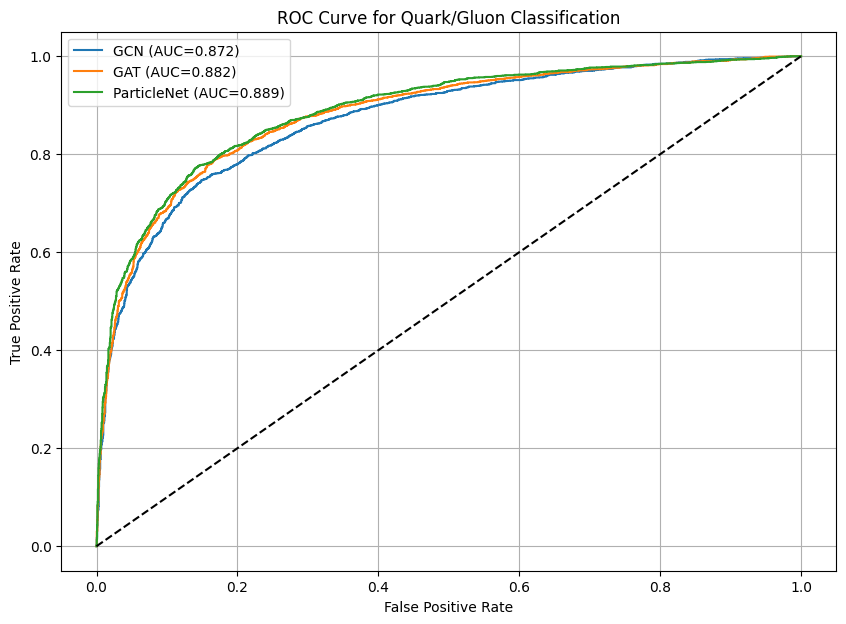

In [ ]:
plt.figure(figsize=(10,7))

fpr_gcn, tpr_gcn, _ = roc_curve(ys_gcn, probs_gcn)
fpr_gat, tpr_gat, _ = roc_curve(ys_gat, probs_gat)
fpr_pn, tpr_pn, _ = roc_curve(ys_pn, probs_pn)

plt.plot(fpr_gcn, tpr_gcn, label=f'GCN (AUC={test_auc_gcn:.3f})')
plt.plot(fpr_gat, tpr_gat, label=f'GAT (AUC={test_auc_gat:.3f})')
plt.plot(fpr_pn, tpr_pn, label=f'ParticleNet (AUC={test_auc_pn:.3f})')

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Quark/Gluon Classification")

plt.legend()
plt.grid(True)

plt.show()

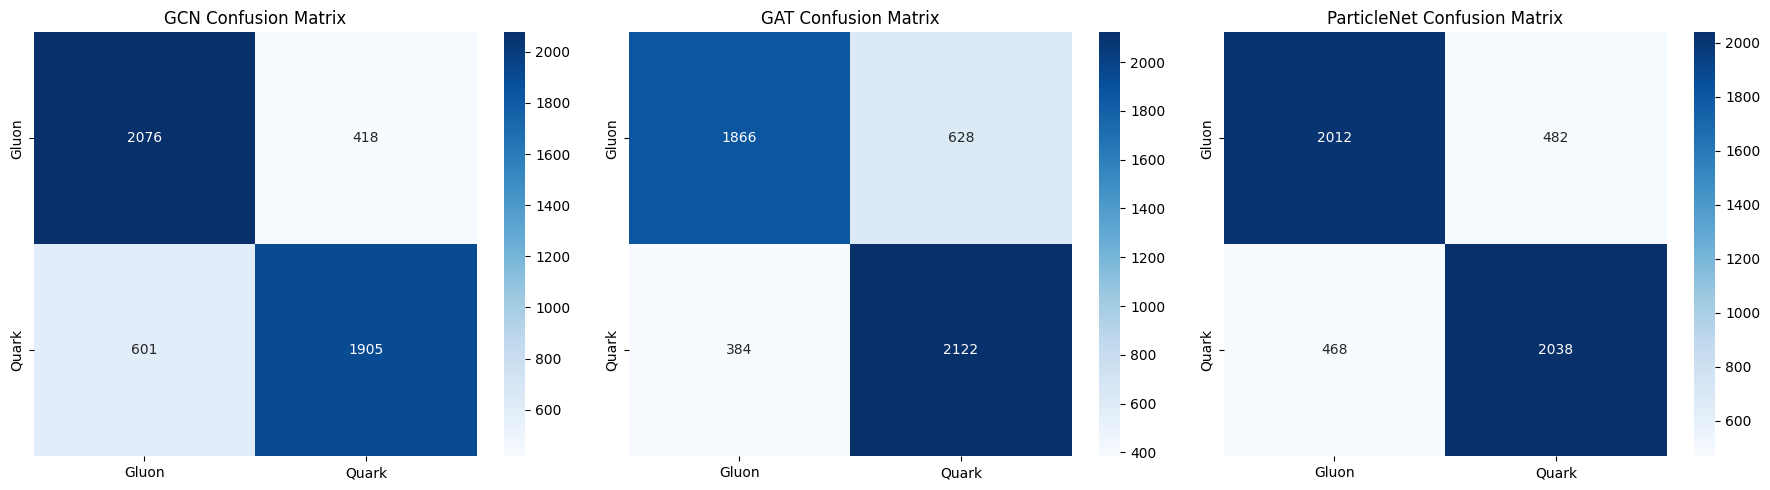

In [ ]:
plt.figure(figsize=(18,5))

plt.subplot(1,3,1)
sns.heatmap(confusion_matrix(ys_gcn,preds_gcn),
            annot=True,fmt='d',cmap='Blues',
            xticklabels=['Gluon','Quark'],
            yticklabels=['Gluon','Quark'])
plt.title("GCN Confusion Matrix")

plt.subplot(1,3,2)
sns.heatmap(confusion_matrix(ys_gat,preds_gat),
            annot=True,fmt='d',cmap='Blues',
            xticklabels=['Gluon','Quark'],
            yticklabels=['Gluon','Quark'])
plt.title("GAT Confusion Matrix")

plt.subplot(1,3,3)
sns.heatmap(confusion_matrix(ys_pn,preds_pn),
            annot=True,fmt='d',cmap='Blues',
            xticklabels=['Gluon','Quark'],
            yticklabels=['Gluon','Quark'])
plt.title("ParticleNet Confusion Matrix")

plt.tight_layout()
plt.show()